<a href="https://colab.research.google.com/github/python4recursion/bookcode/blob/main/5/5_go.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CH05: calculate the liberty of each stone in Go
import random
# fill the board (randomly)
# find the groups of stones (of the same colors)
# calculate the liberty of each group
import sys
import random
options = [' ', 'B', 'W']
class GoGame:
    def __init__(self, side):
        self.side = side
        self.numposition = side * side
        self.stones = [' ' for index in range(self.numposition)]
        self.groups = [-1  for index in range(self.numposition)]
        self.stoneLiberty = [0  for index in range(self.numposition)]
        self.blackLiberty = 0
        self.whiteLiberty = 0
        self.valid = True
    def findNeighbors(self, index):
        upper  = index - 1
        lower = index + 1
        left = index - self.side
        right = index + self.side
        neighbors = []
        col = int(index / self.side)
        row = index % self.side
        side = self.side
        if ((left >= 0) and ((left % side) == row)): # same row
            neighbors.append(left) # valid neighbor
        if ((right < self.numposition) and ((right % side) == row)):
            # same row
            neighbors.append(right)
        if ((upper >= 0) and (int(upper / side) == col)): # same column
            neighbors.append(upper)
        if ((lower < self.numposition) and (int(lower / side) == col)):
            # same column
            neighbors.append(lower)
        return neighbors # a list
    def growGroup(self, index, label, color):
        neighbors = self.findNeighbors(index)
        for nei in (neighbors):
            if ((self.stones[nei] == color) and (self.groups[nei] == -1)):
                self.groups[nei] = label
                self.growGroup(nei, label, color)
    def group(self):
        side = self.side
        self.groups = [-1  for index in range(self.numposition)] # reset
        for index in range(self.numposition):
            if (self.stones[index] != ' '): # black or white
                if (self.groups[index] == -1): # not in a group yet
                    self.groups[index] = index
                    self.growGroup(index, index, self.stones[index])
    def fill(self):
        # fill each intersection by ' ', 'B', or 'W'
        for index in range(self.numposition):
            self.stones[index] = random.choice(options)
        self.group()
        self.stoneLiberty = [0  for index in range(self.side * self.side)]
        self.useLiberty = [False  for index in range(self.side * self.side)]
        self.countLiberty()
    def countLiberty(self):
        self.blackLiberty = 0
        self.whiteLiberty = 0
        for index in range(self.numposition):
            if (self.stones[index] == ' '): # unoccupied
                neighbors = self.findNeighbors(index)
                neighborset = set()
                for nei in (neighbors):
                    neighborset.add(self.groups[nei])
                for grp in (neighborset):
                    if (grp != -1):
                        self.stoneLiberty[grp] += 1
        # fill the liberty values to all stones of the same group
        for index in range(self.numposition):
            if (self.stones[index] != ' '):
                group = self.groups[index]
                for index in range(self.numposition):
                    if (self.groups[index] == group):
                        self.stoneLiberty[index] = self.stoneLiberty[group]
                        if (self.stones[index] == 'B'):
                            self.blackLiberty += self.stoneLiberty[group]
                        else:
                            self.whiteLiberty += self.stoneLiberty[group]
        # detect any stone that has zero liberty
        for index in range(self.numposition):
            if ((self.stones[index] != ' ') and (self.stoneLiberty[index] == 0)):
                print(f'zero liberty of {self.groups[index]}')
                self.valid = False
        self.valid = True
        print(f'black liberty: {self.blackLiberty}')
        print(f'white liberty: {self.whiteLiberty}')
    def getStones(self):
        return self.stones
    def getGroups(self):
        return self.groups
    def getLiberty(self):
        return self.stoneLiberty
    def print(self):
        print('---stones-------------------')
        for index in range(0, self.numposition, self.side):
            print(self.stones[index : index + self.side])
        print('---groups-------------------')
        for index in range(0, self.numposition, self.side):
            print(self.groups[index : index + self.side])
        print('---liberty-------------------')
        for index in range(0, self.numposition, self.side):
            print(self.stoneLiberty[index : index + self.side])

In [ ]:
boardsize = 9
gb = GoGame(boardsize)
gb.fill()
gb.print()

zero liberty of 5
zero liberty of 23
black liberty: 397
white liberty: 2714
---stones-------------------
['W', ' ', 'W', 'W', 'W', 'B', 'W', ' ', ' ']
['W', 'B', 'B', 'W', 'W', 'W', ' ', 'W', 'B']
['B', ' ', 'W', 'W', 'W', 'B', 'W', ' ', 'B']
[' ', ' ', 'W', 'B', 'W', 'W', ' ', ' ', 'B']
['W', 'B', 'W', ' ', 'B', ' ', 'W', 'B', 'B']
[' ', ' ', 'W', 'W', 'B', ' ', 'W', 'B', 'W']
['W', ' ', 'W', 'B', 'B', ' ', 'W', 'B', ' ']
['B', 'B', ' ', 'B', ' ', 'B', 'W', 'W', 'B']
['W', 'W', ' ', ' ', 'W', 'W', 'B', ' ', ' ']
---groups-------------------
[0, -1, 2, 2, 2, 5, 6, -1, -1]
[0, 10, 10, 2, 2, 2, -1, 16, 17]
[18, -1, 2, 2, 2, 23, 24, -1, 17]
[-1, -1, 2, 30, 2, 2, -1, -1, 17]
[36, 37, 2, -1, 40, -1, 42, 17, 17]
[-1, -1, 2, 2, 40, -1, 42, 17, 53]
[54, -1, 2, 40, 40, -1, 42, 17, -1]
[63, 63, -1, 40, -1, 68, 42, 42, 71]
[72, 72, -1, -1, 76, 76, 78, -1, -1]
---liberty-------------------
[1, 0, 10, 10, 10, 0, 2, 0, 0]
[1, 2, 2, 10, 10, 10, 0, 3, 4]
[2, 0, 10, 10, 10, 0, 3, 0, 4]
[0, 0, 10, 1, 10

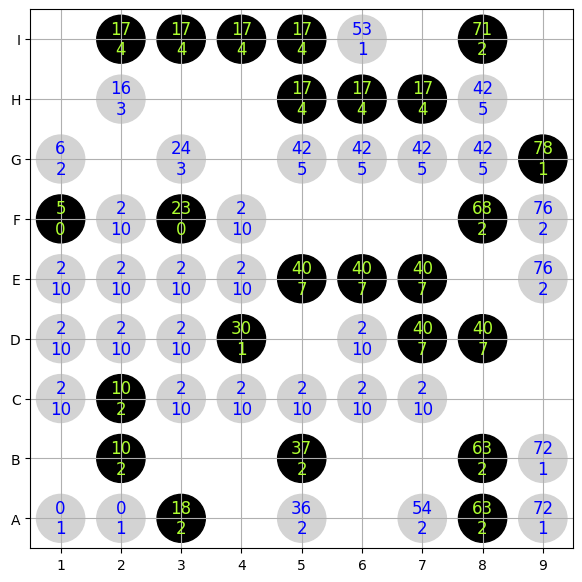

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
def drawGoBoard(board):
    size = board.side
    fig, ax = plt.subplots(figsize=(int(0.7 * size + 1), int(0.7* size + 1)))
    # Set limits to ensure points are at intersections
    ax.set_xlim(0, size)
    ax.set_ylim(0, size)
    ax.set_xticks(np.arange(0.5, size, 1))
    ax.set_yticks(np.arange(0.5, size, 1))
    xlabel = range(1, size + 1)
    ylabel = [chr(num + ord('A') - 1) for num in xlabel]
    ax.set_xticklabels(xlabel)
    ax.set_yticklabels(ylabel)
    ax.grid(True)
    stones = board.getStones()
    groups = board.getGroups()
    liberty = board.getLiberty()
    outlinecolor = 'black'
    for index in range(size * size):
        col = int(index / size)
        row = index % size
        pos = (col + 0.5, row + 0.5)
        if (stones[index] != ' '):
          group = groups[index]
          liberty = board.stoneLiberty[group]
          if (stones[index] == 'B'):
            textcolor = 'greenyellow'
            circle = plt.Circle(pos, 0.4, color= 'black', fill=True)
          elif (stones[index] == 'W'):
            textcolor = 'blue'
            circle = plt.Circle(pos, 0.4, color= 'lightgray', fill=True)
          ax.add_patch(circle)
          ax.text(pos[0], pos[1], f'{group}\n{liberty}', ha='center', va='center', fontsize=12, color=textcolor)
    plt.show()
drawGoBoard(gb)